# Chapter 1. When payments are attached to orders, which rows does each join keep, drop or repeat?

**Week 2, Tuesday · Chapter 1 of 6 · Booked against collected.**

> **The client asks.** "Booked revenue is not collected revenue. Some orders are paid in two
> instalments, some are refunded, some were never paid at all. Show me, order by order, what we
> actually collected against what we booked in Q2. If there is a gap, I want to know which orders
> and which channel."
>
> Anand Iyer, finance controller, Kalpa Retail

The data platform lead added the payments table to the team's access and said, in passing, that
the payments feed "sometimes double-posts when the gateway retries".

**Who needs the answer.** Anand's analyst, who will audit the statement order by order, and you, since you sign the collected number. A join that drops an unpaid order hides it from the collections team, and a join that repeats a paid order sends the team after a customer who paid in full.

**The questions on the way.**
1. What is one row of `orders`, and one row of `payments`?
2. On five orders and seven payments, how many rows does each of the four joins return?
3. Which join answers Anand's question about every booked order?
4. What does a statement that starts from the payments table tell Anand?
5. Can the row counts be predicted from the keys alone, before any join runs?

**The metric at stake.** Collected revenue: the cash that reached Kalpa against its booked orders, each payment counted once. Booked revenue is Monday's number, every Q2 order at its amount whatever its status: Rs 9,84,00,000 over 462 orders.

**What came before, and what this adds.** Monday answered every question from one table, `orders`, where one row is one order, so a sum was a sum of orders. Today a second table arrives, and a join between two tables can change how many rows you are adding up. This chapter traces that on two tables small enough to check by hand, and every later chapter uses what it finds.

**Setup.** The next cell finds the programme's helper, `c2kit`, by walking up from this folder,
connects to the Kalpa warehouse, and creates the two invented tables as TEMP tables on this
notebook's own connection, so they vanish when the notebook stops and the warehouse is never
changed. The same tables and every query below are in `sql/C2_W02_D02_01_what_a_join_keeps_STUDENT.sql`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
from decimal import Decimal

TINY = """DROP TABLE IF EXISTS tiny_orders, tiny_payments;
CREATE TEMP TABLE tiny_orders (
    order_id  text PRIMARY KEY,
    channel   text NOT NULL,
    amount    numeric(12, 2) NOT NULL
);
CREATE TEMP TABLE tiny_payments (
    payment_id    text PRIMARY KEY,
    order_id      text NOT NULL,
    paid_date     date NOT NULL,
    amount        numeric(12, 2) NOT NULL,
    instalment_no integer NOT NULL
);
INSERT INTO tiny_orders VALUES
    ('T-1', 'app',   1000),
    ('T-2', 'web',   2000),
    ('T-3', 'store', 1500),
    ('T-4', 'app',    800),
    ('T-5', 'store',  500);
INSERT INTO tiny_payments VALUES
    ('P-1', 'T-1', '2026-07-03', 1000, 1),
    ('P-2', 'T-2', '2026-07-05', 1200, 1),
    ('P-3', 'T-2', '2026-08-05',  800, 2),
    ('P-4', 'T-3', '2026-07-09', 1500, 1),
    ('P-5', 'T-3', '2026-07-09', 1500, 1),
    ('P-6', 'T-5', '2026-07-12',  500, 1),
    ('P-7', 'T-9', '2026-07-14',  600, 1);"""

conn = kit.connect()
conn.autocommit = True
with conn.cursor() as cur:
    cur.execute(TINY)            # invented, TEMP, so they vanish when this notebook stops


def run(query, params=None):
    """Run a query on this notebook's one connection and return its rows as dictionaries."""
    return kit.sql(query, params, conn=conn)


def one(query, params=None):
    """The first value of the first row, for a query that returns a single number."""
    row = run(query, params)[0]
    return next(iter(row.values()))


def show(rows, caption="", money=()):
    """Rows as the kit's table; columns named in money print as rupees."""
    if not rows:
        return kit.table(["result"], [["no rows"]], caption)
    heads = list(rows[0])
    body = []
    for r in rows:
        line = []
        for h in heads:
            v = r[h]
            if v is None:
                line.append("NULL")
            elif h in money:
                line.append(kit.rupees(v))
            elif isinstance(v, Decimal):
                line.append(f"{int(v):,}" if v == v.to_integral_value() else f"{float(v):,.2f}")
            else:
                line.append(str(v))
        body.append(line)
    kit.table(heads, body, caption)

print(one("SELECT count(*) FROM tiny_orders"), "invented orders and",
      one("SELECT count(*) FROM tiny_payments"), "invented payments are ready;",
      f'the warehouse holds {one("SELECT count(*) FROM orders"):,} orders.')

5 invented orders and 7 invented payments are ready; the warehouse holds 1,000 orders.


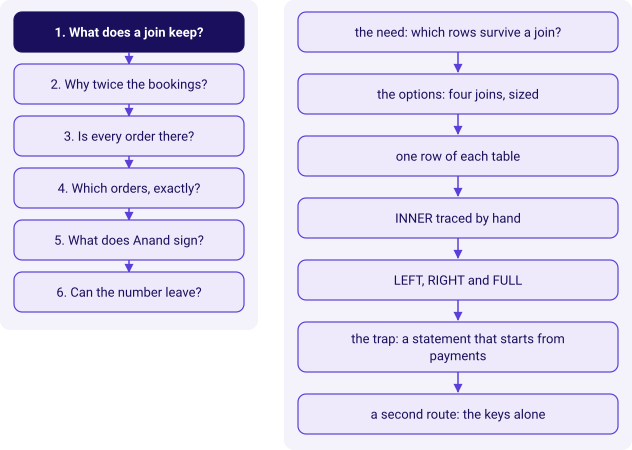

In [2]:
kit.side_by_side(
    kit.ladder(['What does a join keep?', 'Why twice the bookings?', 'Is every order there?', 'Which orders, exactly?', 'What does Anand sign?', 'Can the number leave?'], lit=0, show=False),
    kit.vflow(['the need: which rows survive a join?', 'the options: four joins, sized', 'one row of each table', 'INNER traced by hand', 'LEFT, RIGHT and FULL', 'the trap: a statement that starts from payments', 'a second route: the keys alone'], show=False),
)

## Why must the join be chosen before any total is read?

Anand wants two numbers per order, booked and collected, and they live in two tables. `orders` holds
what was booked: one row per order, with its channel, quarter, status and amount. `payments` holds
what arrived: one row per payment event, with the order it pays, the date, the amount, the method
and the instalment number. Putting the two side by side is a join, and a join has to decide two
things before it adds anything up: what to do with an order that found no payment, and what to do
with an order that found two.

The decision rides on money Anand can act on. An order the statement drops is an order nobody
chases, and at Kalpa's size one large business invoice can be worth several lakh rupees. An order
the statement lists twice looks short-paid on one of its lines, and a collections clerk who
follows the statement rings a customer who has paid in full. The retail story behind Anand's role, how a sale becomes cash and who checks it, is in the domain dossier, `content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, sections 3 and 4.

**Who else faces this.** Razorpay, the Indian payment gateway, documents the same shape from a
merchant's side. Its Orders API "combines multiple payment attempts for a single order"; an order
stays attempted until a payment is captured and then moves to paid; and a merchant who asks for the
payments of one order gets "all the authorised or failed payments for that order", so one order id
appears once in the merchant's orders and several times in the payments list (Razorpay
documentation, About Orders and Fetch Payments for an Order, checked 30 Sep 2026). Every merchant
who puts the two lists side by side meets this chapter's question.

**The two invented tables.** Five orders and seven payments, invented to carry every case Anand
named and the one the platform lead mentioned, so every row can be checked by hand:

| order_id | channel | amount | What happened to it |
|---|---|---|---|
| T-1 | app | 1,000 | Paid once, in full (P-1) |
| T-2 | web | 2,000 | Paid in two instalments, 1,200 and 800 (P-2, P-3) |
| T-3 | store | 1,500 | Paid once, and the gateway posted that payment twice (P-4, P-5) |
| T-4 | app | 800 | Never paid |
| T-5 | store | 500 | Paid once, in full (P-6) |

P-7 is a payment of 600 against T-9, an order that is not in the orders table.

## Which of the four joins answers Anand, and what does each cost on five orders?

Four ways to attach payments to orders, each keeping a different set of rows. The cell below
measures each one on the invented tables: how many rows it returns, how many of the five booked
orders reach the statement, what happens to T-4 (never paid) and to P-7 (a payment with no order),
and how long it takes.

| Option | What it keeps | The question it answers |
|---|---|---|
| A. INNER JOIN | Only the pairs that match | What do the orders that were paid look like? |
| B. LEFT JOIN, orders first | Every order, matched or not | What happened to each order we booked? |
| C. RIGHT JOIN, payments kept | Every payment, matched or not | Which order does each payment belong to? |
| D. FULL OUTER JOIN | Every order and every payment | Where do the two tables fail to meet, on either side? |

Option,Rows out,Booked orders on it,"T-4, never paid","P-7, no order",Orders listed twice,Time
A. INNER,6,4 of 5,dropped,dropped,"T-2, T-3",0.7 ms
"B. LEFT, orders first",7,5 of 5,kept,dropped,"T-2, T-3",0.3 ms
"C. RIGHT, payments kept",7,4 of 5,dropped,kept,"T-2, T-3",0.2 ms
D. FULL OUTER,8,5 of 5,kept,kept,"T-2, T-3",0.2 ms


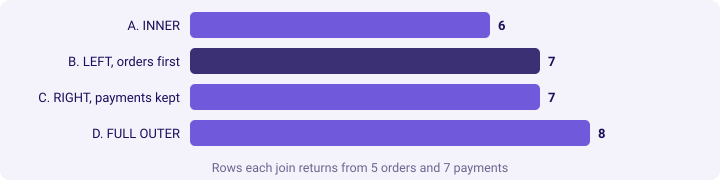

In [3]:
import time
sizing = []
for name, join in [("A. INNER", "JOIN"), ("B. LEFT, orders first", "LEFT JOIN"),
                   ("C. RIGHT, payments kept", "RIGHT JOIN"), ("D. FULL OUTER", "FULL JOIN")]:
    t0 = time.perf_counter()
    rows = run(f"""
        SELECT o.order_id, p.payment_id
        FROM tiny_orders o {join} tiny_payments p ON p.order_id = o.order_id""")
    secs = time.perf_counter() - t0
    booked_ids = {r["order_id"] for r in rows if r["order_id"]}
    repeated = sorted({i for i in booked_ids if sum(1 for r in rows if r["order_id"] == i) > 1})
    sizing.append((name, len(rows), f"{len(booked_ids)} of 5",
                   "kept" if "T-4" in booked_ids else "dropped",
                   "kept" if any(r["payment_id"] == "P-7" for r in rows) else "dropped",
                   ", ".join(repeated), f"{secs * 1000:.1f} ms"))
kit.table(["Option", "Rows out", "Booked orders on it", "T-4, never paid", "P-7, no order",
           "Orders listed twice", "Time"], sizing,
          caption="Four joins on the invented tables: 5 orders in, 7 payments in")
kit.bars([(s[0], s[1]) for s in sizing], lit=[1],
         title="Rows each join returns from 5 orders and 7 payments")
kit.check("only B and D keep all five booked orders",
          [s[2] for s in sizing] == ["4 of 5", "5 of 5", "4 of 5", "5 of 5"], [s[2] for s in sizing])

**The best-fit call.** Option B, the LEFT JOIN with orders on the left, because Anand's question is
about every order Kalpa booked: B is the only option that keeps all five orders and nothing that
is not an order. Every option runs in a few milliseconds here, so speed decides nothing; the rows
each keeps decide everything. The table also shows what B does not fix: T-2 and T-3 come out twice,
which chapter 2 has to deal with before any total is read.

**The fact that would change the call.** The data platform lead asks a different question: is
every payment in the feed explained by a booked order? That question keeps every payment, so it
starts from `payments` (option C, or a LEFT JOIN with payments first). Asked about both sides at
once, before the feed is repaired, it becomes option D.

## 1. What is one row of `orders`, and one row of `payments`?

The grain of a table is what one row stands for. If the key on one side of a join repeats, every
row it matches on the other side comes out once per repeat.

**Predict before you run.** In the warehouse, does an `order_id` ever appear on more than one row of
`payments`? a) never, each order is paid once; b) yes, up to twice; c) yes, up to five times;
d) only for cancelled orders.

table,rows,one row is
orders,1000,one order
payments,1428,one payment event


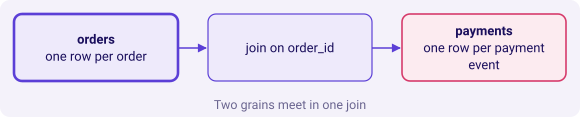

In [4]:
grain = run("""
SELECT 'orders' AS source, count(*) AS row_count, count(DISTINCT order_id) AS order_ids
FROM orders
UNION ALL
SELECT 'payments', count(*), count(DISTINCT order_id)
FROM payments""")
most = one("""
SELECT max(rows_per_id) AS most_rows_for_one_order_id
FROM (SELECT order_id, count(*) AS rows_per_id FROM payments GROUP BY order_id) AS per_id""")
show([{"table": g["source"], "rows": g["row_count"],
        "one row is": "one order" if g["source"] == "orders" else "one payment event"} for g in grain],
     "The grain of the two warehouse tables")
kit.flow(["orders\none row per order", "join on order_id", "payments\none row per payment event"],
         kinds=["known", "plain", "bad"], title="Two grains meet in one join")

**What happened.** The answer is b. `orders` has as many rows as order ids, 1,000 of each, so an
order is one row. `payments` has 1,428 rows, and the check below finds fewer distinct order ids than
rows, with one order id holding at most two of them, so an order can own two payment rows. Anand named one reason, instalments; the
platform lead named another, a gateway retry. Either way a join to `payments` can repeat an order.

In [5]:
kit.check("orders holds one row per order id", grain[0]["row_count"] == grain[0]["order_ids"],
          f'{grain[0]["row_count"]:,} rows, {grain[0]["order_ids"]:,} ids')
kit.check("payments holds more rows than order ids, so an order id repeats",
          grain[1]["row_count"] > grain[1]["order_ids"], f'{grain[1]["row_count"]:,} rows')
kit.check("no order id holds more than two payment rows", most == 2, f"{most}")

## 2. How many rows does the INNER join return on five orders and seven payments?

**Predict before you run.** Join `tiny_orders` to `tiny_payments` on `order_id` with an INNER JOIN.
How many rows come back? a) 5, one per order; b) 6; c) 7, one per payment; d) 8.

In [6]:
inner_rows = run("""
SELECT o.order_id, o.amount AS booked, p.payment_id, p.amount AS paid, p.instalment_no
FROM tiny_orders o
JOIN tiny_payments p ON p.order_id = o.order_id
ORDER BY o.order_id, p.payment_id""")
show(inner_rows, "INNER JOIN on the invented tables: one row per matching pair", money=["booked", "paid"])

order_id,booked,payment_id,paid,instalment_no
T-1,"Rs 1,000",P-1,"Rs 1,000",1
T-2,"Rs 2,000",P-2,"Rs 1,200",1
T-2,"Rs 2,000",P-3,Rs 800,2
T-3,"Rs 1,500",P-4,"Rs 1,500",1
T-3,"Rs 1,500",P-5,"Rs 1,500",1
T-5,Rs 500,P-6,Rs 500,1


**What happened.** The answer is b, six rows. An INNER JOIN writes one row for every pair of an order
and a payment that share an `order_id`: T-1 once, T-2 twice (two instalments), T-3 twice (one
payment posted twice), T-5 once. T-4 is gone because no payment matched it, and P-7 is gone because
no order matched it. Nothing in the join asked whether T-4 belonged in Anand's statement; it simply
did not match.

## 3. What do LEFT, RIGHT and FULL do with the rows that find no partner?

The other three joins keep the same six matched pairs and differ only in the unmatched rows they
add back.

**Predict before you run.** How many rows do the LEFT, RIGHT and FULL joins return, in that order?
a) 5, 7 and 8; b) 7, 7 and 8; c) 5, 5 and 7; d) 7, 6 and 8.

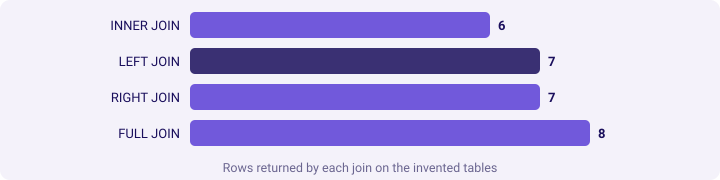

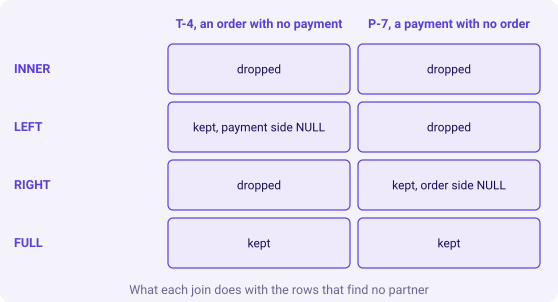

In [7]:
counts = {r["join_type"]: r["row_count"] for r in run("""
SELECT 'INNER' AS join_type, count(*) AS row_count
FROM tiny_orders o JOIN tiny_payments p ON p.order_id = o.order_id
UNION ALL
SELECT 'LEFT', count(*)
FROM tiny_orders o LEFT JOIN tiny_payments p ON p.order_id = o.order_id
UNION ALL
SELECT 'RIGHT', count(*)
FROM tiny_orders o RIGHT JOIN tiny_payments p ON p.order_id = o.order_id
UNION ALL
SELECT 'FULL', count(*)
FROM tiny_orders o FULL JOIN tiny_payments p ON p.order_id = o.order_id""")}
kit.bars([(f"{k} JOIN", v) for k, v in counts.items()], lit=[1],
         title="Rows returned by each join on the invented tables")
kit.matrix(["INNER", "LEFT", "RIGHT", "FULL"],
           ["T-4, an order with no payment", "P-7, a payment with no order"],
           [["dropped", "dropped"], ["kept, payment side NULL", "dropped"],
            ["dropped", "kept, order side NULL"], ["kept", "kept"]],
           title="What each join does with the rows that find no partner")

**What happened.** The answer is b: LEFT returns 7, the six pairs plus T-4 with NULL where its payment
would be; RIGHT returns 7, the six pairs plus P-7 with NULL where its order would be; FULL returns
8, the six plus both. Every join repeats T-2 and T-3, because the repeat comes from the key, never
from the join type.

In [8]:
kit.check("INNER returns 6 rows: every matching pair", counts["INNER"] == 6, f'{counts["INNER"]}')
kit.check("LEFT adds exactly the one order with no payment", counts["LEFT"] - counts["INNER"] == 1,
          f'{counts["LEFT"]} against {counts["INNER"]}')
kit.check("RIGHT adds exactly the one payment with no order", counts["RIGHT"] - counts["INNER"] == 1,
          f'{counts["RIGHT"]} against {counts["INNER"]}')
kit.check("FULL keeps both kinds of orphan", counts["FULL"] == counts["INNER"] + 2, f'{counts["FULL"]}')

## 4. What does a statement that starts from the payments table tell Anand?

**The plausible wrong answer.** A hurried analyst reasons that collected money lives in `payments`,
so the statement should start there: every payment, with its order attached. That is a LEFT JOIN
with `payments` first, which returns the same rows as option C.

**Predict before you run.** On the invented tables, how many of the five booked orders appear on
that statement, and how much cash does it total? a) 5 orders, 5,800; b) 4 orders, 7,100;
c) 5 orders, 6,500; d) 4 orders, 5,000.

payment_id,paid_for,paid,order_id,booked
P-1,T-1,"Rs 1,000",T-1,"Rs 1,000"
P-2,T-2,"Rs 1,200",T-2,"Rs 2,000"
P-3,T-2,Rs 800,T-2,"Rs 2,000"
P-4,T-3,"Rs 1,500",T-3,"Rs 1,500"
P-5,T-3,"Rs 1,500",T-3,"Rs 1,500"
P-6,T-5,Rs 500,T-5,Rs 500
P-7,T-9,Rs 600,NULL,NULL


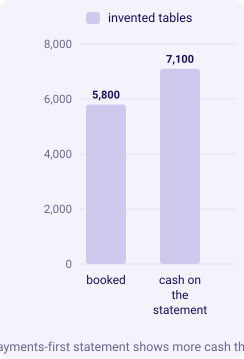

In [9]:
pay_first = run("""
SELECT p.payment_id, p.order_id AS paid_for, p.amount AS paid, o.order_id, o.amount AS booked
FROM tiny_payments p
LEFT JOIN tiny_orders o ON o.order_id = p.order_id
ORDER BY p.payment_id""")
show(pay_first, "The statement started from payments: every payment, its order attached",
     money=["paid", "booked"])
on_statement = {r["order_id"] for r in pay_first if r["order_id"]}
cash = sum(r["paid"] for r in pay_first)
booked_total = one("SELECT sum(amount) FROM tiny_orders")
kit.stats([(f"{len(on_statement)} of 5", "booked orders on it", "T-4 is missing"),
           (f"{int(cash):,}", "cash on the statement", "every payment row"),
           (f"{int(booked_total):,}", "booked", "five orders"),
           (f"{cash / booked_total:.0%}", "collected, as it reads", "of booked")])
kit.columns(["booked", "cash on the statement"],
            [("invented tables", [float(booked_total), float(cash)])],
            title="Invented: the payments-first statement shows more cash than was booked")

**What happened.** The answer is b: four of the five booked orders, and 7,100 of cash against 5,800
booked, so the statement reads as 122 percent collected.

**Why it is wrong.** Anand asked about the orders Kalpa booked, and this statement answers a
different question, which payment belongs to which order. T-4, the one order nobody paid, never
reaches it, so the collections team has nothing to chase. The cash total carries 600 from P-7,
which pays an order that is not in Kalpa's books, and 1,500 from P-5, T-3's payment posted a second
time. A finance controller who reads "we collected more than we booked" stands his collections
team down.

**The check that catches it.** Count the booked orders on the statement against the orders table,
and count the lines with no booked order behind them. Neither check reads a rupee.

In [10]:
orders_first = run("""
SELECT o.order_id, o.amount AS booked, p.payment_id, p.amount AS paid
FROM tiny_orders o
LEFT JOIN tiny_payments p ON p.order_id = o.order_id
ORDER BY o.order_id, p.payment_id""")
missing = one("SELECT count(*) FROM tiny_orders") - len(on_statement)
no_order = sum(1 for r in pay_first if r["order_id"] is None)
kit.check("the payments-first statement misses a booked order", missing == 1, f"{missing} missing")
kit.check("the payments-first statement carries a line with no booked order", no_order == 1,
          f"{no_order} line, P-7")
fixed_ids = {r["order_id"] for r in orders_first}
kit.check("the fix, orders first, puts all five booked orders on the statement", len(fixed_ids) == 5,
          f"{len(fixed_ids)} of 5 across {len(orders_first)} lines")
show(orders_first, "The fix: orders first, so every booked order is on the statement",
     money=["booked", "paid"])

order_id,booked,payment_id,paid
T-1,"Rs 1,000",P-1,"Rs 1,000"
T-2,"Rs 2,000",P-2,"Rs 1,200"
T-2,"Rs 2,000",P-3,Rs 800
T-3,"Rs 1,500",P-4,"Rs 1,500"
T-3,"Rs 1,500",P-5,"Rs 1,500"
T-4,Rs 800,NULL,NULL
T-5,Rs 500,P-6,Rs 500


**The fix, and what changed.** With `orders` first, all five booked orders are on the statement and
T-4 shows NULL where its payment would be, which is exactly the line Anand needs to see. P-7 left
the statement, since it belongs to the platform lead's question. One thing did not change: seven
lines for five orders, with T-2 and T-3 listed twice each. Read line by line, T-2 looks short-paid
on both of its lines, 1,200 of 2,000 on one and 800 of 2,000 on the other, when it was paid in full.
Before any total is read from this join, chapter 2 has to answer what a total does to an order
that appears twice.

> **Kavya's review.** "Tell me the grain of each table, and which rows your join drops, before you
> tell me any total. Start from the table whose every row must survive."

## Can the row counts be predicted from the keys alone, before any join runs?

A join's row count follows from how often each key appears on each side. For a key that appears
`a` times in `orders` and `b` times in `payments`, an INNER JOIN writes `a x b` rows. LEFT adds one
row for every order key that matched nothing, RIGHT one for every payment key that matched nothing,
and FULL both. The cell below counts the keys on each side without joining anything, predicts all
four counts, and compares them with the joins run above.

order_id,rows_in_orders,rows_in_payments
T-1,1,1
T-2,1,2
T-3,1,2
T-4,1,0
T-5,1,1
T-9,0,1


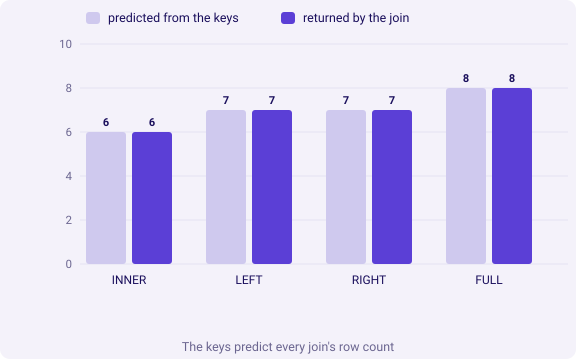

In [11]:
keys = run("""
SELECT k.order_id,
       (SELECT count(*) FROM tiny_orders o WHERE o.order_id = k.order_id)   AS rows_in_orders,
       (SELECT count(*) FROM tiny_payments p WHERE p.order_id = k.order_id) AS rows_in_payments
FROM (SELECT order_id FROM tiny_orders UNION SELECT order_id FROM tiny_payments) AS k
ORDER BY k.order_id""")
show(keys, "How often each key appears on each side, counted without a join")
inner_p = sum(k["rows_in_orders"] * k["rows_in_payments"] for k in keys)
left_p = inner_p + sum(k["rows_in_orders"] for k in keys if k["rows_in_payments"] == 0)
right_p = inner_p + sum(k["rows_in_payments"] for k in keys if k["rows_in_orders"] == 0)
full_p = left_p + right_p - inner_p
predicted = {"INNER": inner_p, "LEFT": left_p, "RIGHT": right_p, "FULL": full_p}
kit.columns(list(predicted), [("predicted from the keys", list(predicted.values())),
                              ("returned by the join", [counts[k] for k in predicted])],
            title="The keys predict every join's row count")
kit.check("the key counts predict all four joins exactly", predicted == counts, str(predicted))

**What happened.** The keys predict 6, 7, 7 and 8, the same four counts the joins returned, and the
prediction never ran a join. This is the second route to use before any join on real data: count
the keys on each side first, and the join's row count is known before it runs. It fails in one
place only, when the join condition is more than key equality, such as the date condition chapter 4
meets; there the prediction has to include the condition.

### [S] INNER against LEFT join: what does each drop or keep?

An INNER JOIN keeps only the rows that match on both sides and drops the rest from both tables. A
LEFT JOIN keeps every row of the left table and fills the right-hand columns with NULL where nothing
matched. Both repeat a left row once for every matching right row, and that last clause is the one
an interviewer is listening for, because it is where a total goes wrong.

### [S] When is an INNER join the honest choice?

When the unmatched rows are outside the question by definition, and the report says so: "for the
orders that were paid, how many days passed before the first payment?" asks only about matches. For
Anand's question it is dishonest, since his question is about every booked order, paid or not.

### Depth: why does a RIGHT JOIN rarely appear in production code?

A RIGHT JOIN is a LEFT JOIN with the two tables swapped, so most teams write every outer join as a
LEFT JOIN with the table whose rows must all survive written first. The query then reads in the
order of the question: start from what must be kept, attach what may be missing.

## What did this chapter answer, one line per question?

1. One row of `orders` is one order, 1,000 of them; one row of `payments` is one payment event, and
   an order id holds up to two of the 1,428 payment rows.
2. On five orders and seven payments, INNER returns 6 rows, LEFT 7, RIGHT 7 and FULL 8.
3. The LEFT JOIN with orders first answers Anand, since it alone keeps all five booked orders and
   nothing that is not an order.
4. A statement started from payments shows 4 of the 5 booked orders and 7,100 of cash against 5,800
   booked, because it drops the unpaid order and carries a retry and a payment with no order.
5. The key counts predict all four row counts without a join: 6, 7, 7 and 8.

**The question this leaves.** The right join still lists T-2 and T-3 twice. What does a total over
those rows report on Kalpa's Q2? That is chapter 2.

In [12]:
kit.check_summary()